<a href="https://colab.research.google.com/github/IOAI-official/IOAI-2026/blob/main/Home%20Task/Home-Task-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Robot Delivery Academy: Preparatory Program

## 1. Problem Description

Welcome to the **Robot Delivery Academy**, the preparatory program for the Robot Training task.

You are working with a small delivery robot on an `8 x 8` city map. In each episode, the robot starts somewhere on the map, picks up a package from one depot, and delivers it to another depot. Some cells are blocked, and every map is slightly different.

For a human programmer, this kind of task may look easy: inspect the map, find a path, pick up the package, deliver it. But the goal here is different. We want to check whether an AI model can learn this behavior from examples instead of being given the full hand-written strategy.

The training principle is supervised learning. We prepare many examples of the form:

```text
observation -> action
```

The model sees what action was taken in each situation and tries to learn the pattern. Later, it must act on new scenarios where the answers are not provided.

### Your Mission

Train a model that can:

1. Learn from provided demonstrations.
2. Predict a useful next action from the current observation.
3. Run for a complete episode and deliver the package.
4. Generalize to validation and test scenarios that were not shown as demonstrations.

### The Challenge

You are given a deliberately small demonstration budget. The interesting question is not whether the task can be solved by a search algorithm, but whether you can train a model that learns enough from limited examples.

A single wrong action can move the robot into states that were rare in the demonstrations, so high action accuracy does not always mean high episode success.


## 2. Download the data

This task's data (three `.pkl` files) lives in the shared **`IOAI-2026/RobotDelivery`** Drive folder. The cell below downloads it into a local `data/` folder — no sign-in or setup, just run it.

In [31]:
!pip install -q gdown
import os
from pathlib import Path
import gdown

# Data lives in the shared IOAI-2026/RobotDelivery folder (public link, no sign-in).
DATA_DIR = Path('data')
if not DATA_DIR.exists() or not any(DATA_DIR.iterdir()):
    gdown.download_folder(id='1DXFDoY9bqulMBFacyDShVIx8Sa7Z5Wpa',
                          output=str(DATA_DIR), quiet=True, use_cookies=False)
os.listdir(DATA_DIR)


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


['test_scenarios.pkl', 'train_demos.pkl', 'valid_scenarios.pkl']

## 3. Understanding the Task Simulator

For this preparatory task, we also provide a small simulator. It is mainly here to make the task easier to understand: you can use it to inspect scenario conditions, replay demonstration trajectories, and visualize the solutions produced by your model.

The task is a small grid delivery problem.

- The grid size is `8 x 8`.
- There are six depot cells: `A`, `B`, `C`, `D`, `E`, `F`.
- One depot contains the package.
- Another depot is the destination.
- The robot must move to the package, pick it up, move to the destination, and drop it off.
- Walls block movement.

The simulator is included directly in this notebook so it works as a single Google Colab file. It is used to show examples and to check complete episodes after training. The visual helper below can also save and display animated GIFs.


In [32]:
import json
import pickle
import random
import zipfile
from collections import Counter
from pathlib import Path
from typing import Any

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from IPython.display import Image as NotebookImage, display
from PIL import Image as PILImage, ImageDraw
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

GRID_SIZE = 8
N_DEPOTS = 6
MAX_STEPS = 120
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ACTION_NAMES = {
    0: "south",
    1: "north",
    2: "east",
    3: "west",
    4: "pickup",
    5: "dropoff",
}

ACTION_DELTAS = {
    0: (1, 0),
    1: (-1, 0),
    2: (0, 1),
    3: (0, -1),
}

DEPOT_NAMES = ["A", "B", "C", "D", "E", "F"]

print("data dir:", DATA_DIR)
print("device:", DEVICE)


data dir: data
device: cuda


In [33]:
class DeliverySimulator8x8:
    """Run one 8x8 delivery episode."""

    def reset(self, scenario: dict[str, Any]) -> tuple[int, int, int, int]:
        """Start a scenario and return the compact state."""
        self.step_count = 0
        self.carrying = False
        self.walls = {tuple(cell) for cell in scenario["walls"]}
        self.depots = [tuple(cell) for cell in scenario["depots"]]
        self.agent_pos = tuple(scenario["agent_pos"])
        self.package_location = int(scenario["package_location"])
        self.destination = int(scenario["destination"])
        return self.state()

    def state(self) -> tuple[int, int, int, int]:
        """Return row, column, package field, and destination."""
        package_field = N_DEPOTS if self.carrying else self.package_location
        return int(self.agent_pos[0]), int(self.agent_pos[1]), int(package_field), int(self.destination)

    def can_enter(self, row: int, col: int) -> bool:
        """Check whether the robot can occupy a cell."""
        return 0 <= row < GRID_SIZE and 0 <= col < GRID_SIZE and (row, col) not in self.walls

    def valid_action_mask(self) -> np.ndarray:
        """Return the currently valid actions."""
        row, col, _, destination = self.state()
        mask = np.zeros(6, dtype=bool)
        for action, (dr, dc) in ACTION_DELTAS.items():
            mask[action] = self.can_enter(row + dr, col + dc)
        mask[4] = (not self.carrying) and self.agent_pos == self.depots[self.package_location]
        mask[5] = self.carrying and self.agent_pos == self.depots[destination]
        return mask

    def observation(self) -> dict[str, Any]:
        """Build the model observation for the current state."""
        row, col, package_field, destination = self.state()
        carrying = package_field == N_DEPOTS
        dest_row, dest_col = self.depots[destination]
        target_row, target_col = (dest_row, dest_col) if carrying else self.depots[package_field]

        grid = np.zeros((6, GRID_SIZE, GRID_SIZE), dtype=np.float32)
        for wr, wc in self.walls:
            grid[0, wr, wc] = 1.0
        for dr, dc in self.depots:
            grid[1, dr, dc] = 1.0
        grid[2, row, col] = 1.0
        if not carrying:
            pr, pc = self.depots[package_field]
            grid[3, pr, pc] = 1.0
        grid[4, dest_row, dest_col] = 1.0
        grid[5, :, :] = float(carrying)

        blocked_moves = [float(not self.can_enter(row + dr, col + dc)) for dr, dc in ACTION_DELTAS.values()]
        vector = np.array(
            [
                row / (GRID_SIZE - 1),
                col / (GRID_SIZE - 1),
                package_field / N_DEPOTS,
                destination / (N_DEPOTS - 1),
                float(carrying),
                target_row / (GRID_SIZE - 1),
                target_col / (GRID_SIZE - 1),
                (target_row - row) / (GRID_SIZE - 1),
                (target_col - col) / (GRID_SIZE - 1),
                *blocked_moves,
            ],
            dtype=np.float32,
        )
        return {"grid": grid, "vector": vector, "action_mask": self.valid_action_mask(), "state": self.state()}

    def step(self, action: int) -> tuple[tuple[int, int, int, int], bool, bool, dict[str, Any]]:
        """Apply one action and report episode status."""
        action = int(action)
        done = False
        info = {"invalid_pickup_or_dropoff": False}

        if action in ACTION_DELTAS:
            dr, dc = ACTION_DELTAS[action]
            row, col = self.agent_pos[0] + dr, self.agent_pos[1] + dc
            if self.can_enter(row, col):
                self.agent_pos = (row, col)
        elif action == 4 and (not self.carrying) and self.agent_pos == self.depots[self.package_location]:
            self.carrying = True
        elif action == 5 and self.carrying and self.agent_pos == self.depots[self.destination]:
            done = True
            self.carrying = False
            self.package_location = self.destination
        elif action in (4, 5):
            info["invalid_pickup_or_dropoff"] = True
        else:
            raise ValueError(f"unknown action: {action}")

        self.step_count += 1
        return self.state(), done, self.step_count >= MAX_STEPS and not done, info

    def render(self) -> str:
        """Return an ASCII rendering of the current grid."""
        grid = [["." for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]
        for row, col in self.walls:
            grid[row][col] = "#"
        for i, (row, col) in enumerate(self.depots):
            grid[row][col] = DEPOT_NAMES[i]

        agent_row, agent_col = self.agent_pos
        grid[agent_row][agent_col] = "T*" if self.carrying else "T"
        rows = [" ".join(f"{cell:>2}" for cell in row) for row in grid]
        package_name = "in taxi" if self.carrying else DEPOT_NAMES[self.package_location]
        rows.append(f"package={package_name}, destination={DEPOT_NAMES[self.destination]}")
        return "\n".join(rows)


In [34]:
CELL_SIZE = 56
FRAME_FOOTER = 44
DEPOT_COLORS = ["#ef4444", "#3b82f6", "#22c55e", "#f59e0b", "#a855f7", "#06b6d4"]


def draw_episode_frame(simulator, step=0, action_name="start"):
    """Render the current simulator state as a PIL image."""
    width = GRID_SIZE * CELL_SIZE
    height = GRID_SIZE * CELL_SIZE + FRAME_FOOTER
    image = PILImage.new("RGB", (width, height), "#f8fafc")
    draw = ImageDraw.Draw(image)

    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            x0, y0 = col * CELL_SIZE, row * CELL_SIZE
            x1, y1 = x0 + CELL_SIZE, y0 + CELL_SIZE
            fill = "#334155" if (row, col) in simulator.walls else "#f8fafc"
            draw.rectangle([x0, y0, x1, y1], fill=fill, outline="#cbd5e1")

    target_id = simulator.destination if simulator.carrying else simulator.package_location
    for depot_id, (row, col) in enumerate(simulator.depots):
        x0, y0 = col * CELL_SIZE + 8, row * CELL_SIZE + 8
        x1, y1 = x0 + CELL_SIZE - 16, y0 + CELL_SIZE - 16
        color = DEPOT_COLORS[depot_id]
        draw.rounded_rectangle([x0, y0, x1, y1], radius=10, fill=color)
        draw.text((x0 + 14, y0 + 9), DEPOT_NAMES[depot_id], fill="white")
        if depot_id == target_id:
            draw.rounded_rectangle([x0 - 4, y0 - 4, x1 + 4, y1 + 4], radius=14, outline="#111827", width=4)

    row, col = simulator.agent_pos
    cx, cy = col * CELL_SIZE + CELL_SIZE // 2, row * CELL_SIZE + CELL_SIZE // 2
    draw.ellipse([cx - 18, cy - 18, cx + 18, cy + 18], fill="#111827")
    draw.text((cx - 5, cy - 8), "T", fill="white")
    if simulator.carrying:
        draw.rectangle([cx + 10, cy - 24, cx + 25, cy - 9], fill="#f97316", outline="#9a3412")

    package = "in robot" if simulator.carrying else DEPOT_NAMES[simulator.package_location]
    footer = f"step {step:02d} | action: {action_name} | package: {package} -> {DEPOT_NAMES[simulator.destination]}"
    draw.rectangle([0, GRID_SIZE * CELL_SIZE, width, height], fill="#e2e8f0")
    draw.text((12, GRID_SIZE * CELL_SIZE + 14), footer, fill="#0f172a")
    return image


def show_episode_gif(scenario, actions, path="episode.gif", duration=450):
    """Save and display an animated GIF for one action sequence."""
    simulator = DeliverySimulator8x8()
    simulator.reset(scenario)
    frames = [draw_episode_frame(simulator)]
    for step, action in enumerate(actions, start=1):
        simulator.step(action)
        frames.append(draw_episode_frame(simulator, step, ACTION_NAMES[action]))
    frames[0].save(path, save_all=True, append_images=frames[1:], duration=duration, loop=0)
    display(NotebookImage(filename=path))



## 4. Dataset

### 4.1 Provided Training Data

You are provided with expert demonstrations saved in `data/train_demos.pkl`.

Each trajectory contains observations and expert actions from one successful delivery episode.

**Data Format:**

```python
{
    "trajectories": [
        {
            "layout_id": str,
            "episode_seed": int,
            "scenario": dict,
            "observations": [
                {
                    "grid": np.array,       # shape: (6, 8, 8)
                    "vector": np.array,     # shape: (13,)
                    "action_mask": np.array,# shape: (6,)
                    "state": tuple
                },
                ...
            ],
            "actions": [int, ...],       # action IDs 0-5
            "success": bool,
            "num_steps": int
        },
        ...
    ]
}
```

### 4.2 Validation and Test Scenarios

You are also provided with:

- `data/valid_scenarios.pkl`
- `data/test_scenarios.pkl`

These files contain delivery scenarios without expert action labels. They are used to run your trained model and check complete-episode success.


In [35]:
with (DATA_DIR / "train_demos.pkl").open("rb") as f:
    train_data = pickle.load(f)
with (DATA_DIR / "valid_scenarios.pkl").open("rb") as f:
    valid_scenarios = pickle.load(f)
with (DATA_DIR / "test_scenarios.pkl").open("rb") as f:
    test_scenarios = pickle.load(f)

train_trajectories = train_data["trajectories"]
steps = [t["num_steps"] for t in train_trajectories]

print("Loaded data")
print("  training demonstrations:", len(train_trajectories))
print("  validation scenarios:", len(valid_scenarios))
print("  test scenarios:", len(test_scenarios))
print("  training state-action samples:", sum(steps))
print("  average demonstration length:", f"{np.mean(steps):.2f}")
print("  expert success rate:", f"{100 * np.mean([t['success'] for t in train_trajectories]):.1f}%")


Loaded data
  training demonstrations: 400
  validation scenarios: 200
  test scenarios: 1600
  training state-action samples: 5327
  average demonstration length: 13.32
  expert success rate: 100.0%


In [36]:
example = train_trajectories[0]
print("Example trajectory")
print("  layout_id:", example["layout_id"])
print("  episode_seed:", example["episode_seed"])
print("  num_steps:", example["num_steps"])
print("  actions:", [ACTION_NAMES[a] for a in example["actions"]])

obs0 = example["observations"][0]
print("\nObservation")
print("  grid shape:", obs0["grid"].shape)
print("  vector shape:", obs0["vector"].shape)
print("  valid actions:", [ACTION_NAMES[i] for i, ok in enumerate(obs0["action_mask"]) if ok])

simulator = DeliverySimulator8x8()
simulator.reset(example["scenario"])
print("\nInitial frame")
print(simulator.render())

print("\nAnimated example")
# show_episode_gif(example["scenario"], example["actions"], path="expert_demo.gif")



Example trajectory
  layout_id: train_0000
  episode_seed: 100000
  num_steps: 23
  actions: ['north', 'north', 'north', 'east', 'east', 'east', 'east', 'east', 'pickup', 'south', 'west', 'south', 'south', 'south', 'south', 'south', 'west', 'west', 'west', 'west', 'west', 'west', 'dropoff']

Observation
  grid shape: (6, 8, 8)
  vector shape: (13,)
  valid actions: ['south', 'north', 'east']

Initial frame
 .  .  .  .  .  .  .  A
 .  #  .  .  E  #  D  .
 .  .  .  .  .  .  .  #
 .  #  T  .  .  #  .  .
 F  .  .  #  #  .  .  .
 .  .  .  .  .  #  .  .
 B  .  .  .  .  .  .  .
 .  .  .  .  .  .  .  .
package=A, destination=B

Animated example


## 5. Task

### 5.1 Objective

Train a behavioral cloning action model that:

1. Takes the current observation as input.
2. Predicts the expert's next action.
3. Runs step by step in a full delivery episode.
4. Achieves high success rate on validation and test scenarios.

### 5.2 Input and Output

**Input observation:**

- `grid`: `6 x 8 x 8` tensor with walls, depots, robot position, package position, destination, and carrying flag.
- `vector`: 13 numerical features with normalized position and target information.
- `action_mask`: 6 binary values showing which actions are currently valid.

**Output action:**

A single integer from `0` to `5`:

| id | action |
|---:|---|
| 0 | south |
| 1 | north |
| 2 | east |
| 3 | west |
| 4 | pickup |
| 5 | dropoff |

### 5.3 Training Approach

Behavioral cloning is supervised learning:

1. Extract `(observation, expert_action)` pairs from demonstrations.
2. Train a neural network classifier.
3. Use cross-entropy loss between predicted action logits and expert actions.
4. Run the trained model in complete episodes.

### 5.4 Improving Beyond the Baseline

The baseline below is intentionally simple. Better solutions may come from better input representation, a model that matches the structure of the task, stronger training, and careful analysis of failed episodes.


## 6. Submission

### 6.1 What to Submit

Submit a notebook that produces a file named `predictions.zip` containing:

1. `predictions.jsonl` — predicted action sequences for all test scenarios.

### 6.2 Prediction Format

Each line in `predictions.jsonl` should be one JSON object:

```json
{"layout_id": "test_0000", "episode_seed": 300000, "actions": [1, 1, 2, 4, 0, 5]}
```

**Fields:**

- `layout_id`: scenario layout identifier.
- `episode_seed`: scenario seed.
- `actions`: list of action IDs, each integer from `0` to `5`.

### 6.3 How Evaluation Works

1. The evaluator reads your predicted actions.
2. For each test scenario, it starts from the provided scenario state.
3. It replays your actions step by step.
4. Success means the package is delivered to the destination.

### 6.4 Constraints

- Use the provided demonstrations for training.
- Do not use expert action labels for validation or test scenarios.
- Do not generate additional expert trajectories with search, planning, or another expert model.
- Your final prediction process should be deterministic.
- Your submitted notebook should generate `predictions.zip` from scratch.
- Rule-based or hard-coded solutions may be reviewed by the Scientific Committee.


## 7. Scoring

### 7.1 Evaluation Metric

**Success Rate (SR):**

```text
SR = (# successful delivery episodes) / (# total episodes)
```

An episode is successful if the package is delivered to the destination within the step limit.

### 7.2 Diagnostics

The notebook also reports:

- `avg_steps`: average number of steps used per episode.
- `avg_invalid_pickup_or_dropoff`: average number of invalid pickup/dropoff attempts.

These diagnostics are not a replacement for success rate, but they help debug model behavior.


## 8. Baseline & Training

Below is a complete baseline implementation using a simple MLP.

**Baseline Key Limitations:**

- The grid is flattened, so spatial structure is mostly lost.
- Rare actions such as `pickup` and `dropoff` are harder to learn.
- Action masking is used only during inference, not during training.
- The architecture is small and intended only as a starting point.

**Your task:** improve the model and training procedure to achieve better episode success.


### 8.1 Create Supervised Training Samples


In [37]:
# (#8) Data augmentation: the 8 symmetries of the square (rotations + mirror).
# A rotated/mirrored map is a perfectly valid scenario, so every demo step gives
# 8 training examples -- as long as the move actions and the direction-dependent
# vector features are rotated the same way as the grid.
#
# np.rot90 maps (r, c) -> (N-1-c, r), i.e. a direction (dr, dc) -> (-dc, dr).
ROT_PERM = [2, 3, 1, 0, 4, 5]   # south->east, north->west, east->north, west->south
FLIP_PERM = [0, 1, 3, 2, 4, 5]  # left-right mirror: east <-> west


def rotate_sample(grid, vector):
    """Rotate one observation by 90 degrees (grid + the direction-dependent features)."""
    v = vector.copy()
    v[0], v[1] = 1.0 - vector[1], vector[0]  # robot row / col (normalized to [0, 1])
    v[5], v[6] = 1.0 - vector[6], vector[5]  # target row / col
    v[7], v[8] = -vector[8], vector[7]       # target deltas
    for a in range(4):
        v[9 + ROT_PERM[a]] = vector[9 + a]   # blocked-move flags, indexed by action
    return np.rot90(grid, k=1, axes=(-2, -1)), v


def mirror_sample(grid, vector):
    """Mirror one observation left-right."""
    v = vector.copy()
    v[1] = 1.0 - vector[1]
    v[6] = 1.0 - vector[6]
    v[8] = -vector[8]
    for a in range(4):
        v[9 + FLIP_PERM[a]] = vector[9 + a]
    return np.flip(grid, axis=-1), v


def augment_sample(grid, vector, action, rng):
    """Apply a random mirror + rotation to one (grid, vector, action) sample."""
    if rng.random() < 0.5:
        grid, vector = mirror_sample(grid, vector)
        action = FLIP_PERM[action]
    for _ in range(int(rng.integers(4))):
        grid, vector = rotate_sample(grid, vector)
        action = ROT_PERM[action]
    return np.ascontiguousarray(grid), vector, action


class DeliveryDemoDataset(Dataset):
    """Store demonstration steps as supervised examples (grid + vector)."""

    def __init__(self, trajectories, augment=False):
        """Collect all observation-action pairs."""
        self.samples = [
            (obs, int(action))
            for trajectory in trajectories
            for obs, action in zip(trajectory["observations"], trajectory["actions"], strict=True)
        ]
        self.augment = augment
        self.aug_rng = np.random.default_rng(SEED)

    def __len__(self):
        """Return the number of supervised examples."""
        return len(self.samples)

    def __getitem__(self, idx):
        """Return grid tensor, vector features, and action label."""
        obs, action = self.samples[idx]
        grid, vector = obs['grid'], obs['vector']
        if self.augment:  # (#8) a fresh random symmetry every time the sample is drawn
            grid, vector, action = augment_sample(grid, vector, action, self.aug_rng)
        return (
            torch.tensor(grid, dtype=torch.float32),
            torch.tensor(vector, dtype=torch.float32),
            torch.tensor(action, dtype=torch.long),
        )


# (#6) Split by *trajectory* (not by sample) so no episode leaks across the boundary.
# The held-out trajectories give honest episode-success feedback for early stopping.
split_rng = np.random.default_rng(SEED)
perm = split_rng.permutation(len(train_trajectories))
n_holdout = int(0.15 * len(train_trajectories))
holdout_ids = set(perm[:n_holdout].tolist())

train_traj = [t for i, t in enumerate(train_trajectories) if i not in holdout_ids]
holdout_traj = [t for i, t in enumerate(train_trajectories) if i in holdout_ids]
holdout_scenarios = [t["scenario"] for t in holdout_traj]

train_dataset = DeliveryDemoDataset(train_traj, augment=True)  # (#8) augment training only
holdout_dataset = DeliveryDemoDataset(holdout_traj)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# (#7) Inverse-frequency class weights so rare pickup/dropoff are not drowned out.
# Counted from the raw labels (augmentation only permutes the four move actions).
action_counts = np.unique_counts([action for _, action in train_dataset.samples])
counts = action_counts.counts
class_weights = torch.tensor(counts.sum() / (6.0 * counts), dtype=torch.float32)

grid0, vec0, y0 = train_dataset[0]
print("Created dataset")
print("  train trajectories:", len(train_traj), "| holdout trajectories:", len(holdout_traj))
print("  train state-action samples:", len(train_dataset), "(x8 symmetries via augmentation)")
print("  grid shape:", tuple(grid0.shape), "| vector dim:", vec0.numel())
print("  first action:", int(y0), ACTION_NAMES[int(y0)])
print("  class weights:", {ACTION_NAMES[a]: round(float(class_weights[a]), 3) for a in range(6)})


Created dataset
  train trajectories: 340 | holdout trajectories: 60
  train state-action samples: 4500 (x8 symmetries via augmentation)
  grid shape: (6, 8, 8) | vector dim: 13
  first action: 1 north
  class weights: {'south': 0.832, 'north': 0.768, 'east': 0.8, 'west': 0.746, 'pickup': 2.206, 'dropoff': 2.206}


### 8.2 Define Action Model

A two-branch model: a CNN keeps the full `8 x 8` spatial structure (flattened, **not** globally pooled, so the robot's position survives) and is fused with a small MLP over the numeric `vector` features (which include the target deltas). Trained with class-weighted cross-entropy so the rare `pickup`/`dropoff` actions are not drowned out.


In [38]:
example["scenario"]

{'layout_id': 'train_0000',
 'layout_seed': 10000,
 'episode_seed': 100000,
 'walls': ((1, 1), (1, 5), (2, 7), (3, 1), (3, 5), (4, 3), (4, 4), (5, 5)),
 'depots': ((0, 7), (6, 0), (3, 2), (1, 6), (1, 4), (4, 0)),
 'agent_pos': (3, 2),
 'package_location': 0,
 'destination': 1}

In [39]:
len(train_trajectories[0]['observations'][0]['grid'].flatten())

384

In [40]:
class ActionModel(nn.Module):
    """Predict the next action from the spatial grid and the vector features."""

    def __init__(self, n_actions=6, vector_dim=13):
        super().__init__()

        # (#1) Keep the 8x8 resolution all the way through, then Flatten.
        # No global pooling -> the agent's *position* survives into the head.
        self.conv = nn.Sequential(
            nn.Conv2d(6, 32, 3, 1, 1, bias=False), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, 1, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, 1, 1, bias=False), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Flatten(),  # -> 64 * 8 * 8 = 4096
        )

        # (#2) Small MLP for the numeric features (incl. target deltas), fused with the map.
        self.vector_mlp = nn.Sequential(
            nn.Linear(vector_dim, 64), nn.ReLU(),
        )

        self.head = nn.Sequential(
            nn.Linear(64 * GRID_SIZE * GRID_SIZE + 64, 256), nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, n_actions),
        )

    def forward(self, grid, vector):
        """Return action logits from grid and vector inputs."""
        spatial = self.conv(grid)
        numeric = self.vector_mlp(vector)
        return self.head(torch.cat([spatial, numeric], dim=1))


model = ActionModel().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)  # (#7) higher LR
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))  # (#7) weighted loss

print(model)
print("parameters:", sum(p.numel() for p in model.parameters()))


ActionModel(
  (conv): Sequential(
    (0): Conv2d(6, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (vector_mlp): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): ReLU()
  )
  (head): Sequential(
    (0): Linear(in_features=4160, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=6, bias=True)
  )
)
parameters: 1124998


### 8.3 Train the Action Model


In [41]:
@torch.no_grad()
def dataset_action_accuracy(dataset):
    """Measure action accuracy on a dataset (grid, vector, action)."""
    model.eval()
    correct = total = 0
    for grid, vector, y in DataLoader(dataset, batch_size=1024):
        pred = model(grid.to(DEVICE), vector.to(DEVICE)).argmax(dim=1).cpu()
        correct += int((pred == y).sum())
        total += int(y.numel())
    return correct / total


@torch.no_grad()
def holdout_episode_success(scenarios, max_steps=MAX_STEPS):
    """(#6) Roll out full episodes on held-out scenarios with masked argmax (#3)."""
    model.eval()
    wins = 0
    for scenario in scenarios:
        sim = DeliverySimulator8x8()
        sim.reset(scenario)
        done = False
        for _ in range(max_steps):
            obs = sim.observation()
            grid = torch.tensor(obs['grid'], dtype=torch.float32, device=DEVICE).unsqueeze(0)
            vector = torch.tensor(obs['vector'], dtype=torch.float32, device=DEVICE).unsqueeze(0)
            logits = model(grid, vector).squeeze(0)
            mask = torch.tensor(np.asarray(obs['action_mask']), dtype=torch.bool, device=DEVICE)
            logits[~mask] = float('-inf')
            _, done, timed_out, _ = sim.step(int(logits.argmax().item()))
            if done or timed_out:
                break
        wins += int(done)
    return wins / len(scenarios)


EPOCHS = 60
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

best_success = -1.0
best_state = None

for epoch in tqdm(range(1, EPOCHS + 1)):
    model.train()
    total_loss = total_examples = 0

    for grid, vector, y in train_loader:
        grid, vector, y = grid.to(DEVICE), vector.to(DEVICE), y.to(DEVICE)
        loss = criterion(model(grid, vector), y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += float(loss.item()) * len(y)
        total_examples += len(y)
    scheduler.step()

    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        sr = holdout_episode_success(holdout_scenarios)
        if sr > best_success:  # (#6) select the checkpoint by episode success, not accuracy
            best_success = sr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"epoch {epoch:02d} | loss {total_loss / total_examples:.4f} "
              f"| train acc {dataset_action_accuracy(train_dataset):.3f} "
              f"| holdout acc {dataset_action_accuracy(holdout_dataset):.3f} "
              f"| holdout SR {sr:.3f} | best SR {best_success:.3f}")

if best_state is not None:
    model.load_state_dict(best_state)
print("Restored best checkpoint | holdout episode SR:", round(best_success, 3))


  0%|          | 0/60 [00:00<?, ?it/s]

epoch 01 | loss 1.9524 | train acc 0.152 | holdout acc 0.146 | holdout SR 0.033 | best SR 0.033
epoch 05 | loss 0.4047 | train acc 0.812 | holdout acc 0.785 | holdout SR 0.717 | best SR 0.717
epoch 10 | loss 0.2807 | train acc 0.854 | holdout acc 0.868 | holdout SR 0.767 | best SR 0.767
epoch 15 | loss 0.2527 | train acc 0.872 | holdout acc 0.855 | holdout SR 0.783 | best SR 0.783
epoch 20 | loss 0.2124 | train acc 0.883 | holdout acc 0.837 | holdout SR 0.817 | best SR 0.817
epoch 25 | loss 0.1892 | train acc 0.900 | holdout acc 0.874 | holdout SR 0.850 | best SR 0.850
epoch 30 | loss 0.1602 | train acc 0.913 | holdout acc 0.849 | holdout SR 0.783 | best SR 0.850
epoch 35 | loss 0.1409 | train acc 0.931 | holdout acc 0.862 | holdout SR 0.850 | best SR 0.850
epoch 40 | loss 0.1192 | train acc 0.944 | holdout acc 0.906 | holdout SR 0.833 | best SR 0.850
epoch 45 | loss 0.0974 | train acc 0.961 | holdout acc 0.878 | holdout SR 0.800 | best SR 0.850
epoch 50 | loss 0.0861 | train acc 0.968

### 8.4 Evaluation Functions

Action accuracy is useful, but the main check is complete-episode success. A model can predict many individual actions correctly and still fail after one early mistake.


In [42]:
@torch.no_grad()
def model_action(obs):
    """Choose the highest-logit *valid* action for one observation (#2, #3)."""
    model.eval()
    grid = torch.tensor(obs['grid'], dtype=torch.float32, device=DEVICE).unsqueeze(0)
    vector = torch.tensor(obs['vector'], dtype=torch.float32, device=DEVICE).unsqueeze(0)
    logits = model(grid, vector).squeeze(0)
    # (#3) Never emit an illegal action: mask invalid moves / pickup / dropoff.
    mask = torch.tensor(np.asarray(obs['action_mask']), dtype=torch.bool, device=DEVICE)
    if mask.any():
        logits[~mask] = float('-inf')
    return int(logits.argmax().item())


def run_episode(scenario, action_fn, max_steps=MAX_STEPS, render=False):
    """Run an action model on one scenario."""
    simulator = DeliverySimulator8x8()
    simulator.reset(scenario)
    frames, actions = [], []
    invalid_pickup_or_dropoff = 0
    done = False

    if render:
        frames.append(simulator.render())

    for _ in range(max_steps):
        action = int(action_fn(simulator.observation()))
        _, done, timed_out, info = simulator.step(action)
        actions.append(action)
        invalid_pickup_or_dropoff += int(info["invalid_pickup_or_dropoff"])
        if render:
            frames.append(simulator.render())
        if done or timed_out:
            break

    return {
        "success": done,
        "steps": len(actions),
        "invalid_pickup_or_dropoff": invalid_pickup_or_dropoff,
        "actions": actions,
        "frames": frames,
    }


def evaluate_action_model(scenarios, action_fn, limit=None):
    """Evaluate complete-episode success on a scenario list."""
    results = [run_episode(s, action_fn) for s in tqdm(scenarios[:limit])]
    return {
        "success_rate": float(np.mean([r["success"] for r in results])),
        "avg_steps": float(np.mean([r["steps"] for r in results])),
        "avg_invalid_pickup_or_dropoff": float(np.mean([r["invalid_pickup_or_dropoff"] for r in results])),
        "results": results,
    }


rng = np.random.default_rng(SEED)


def random_action_model(obs):
    """Sample a random action."""
    return int(rng.integers(6))


def mlp_action_model(obs):
    """Use the trained action model."""
    return model_action(obs)


In [43]:
EVAL_LIMIT = 100  # set to None for all validation scenarios

random_eval = evaluate_action_model(valid_scenarios, random_action_model, limit=EVAL_LIMIT)
mlp_eval = evaluate_action_model(valid_scenarios, mlp_action_model, limit=EVAL_LIMIT)

for name, metrics in [("random", random_eval), ("MLP", mlp_eval)]:
    print(name, {k: v for k, v in metrics.items() if k != "results"})


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

random {'success_rate': 0.04, 'avg_steps': 118.86, 'avg_invalid_pickup_or_dropoff': 38.56}
MLP {'success_rate': 0.84, 'avg_steps': 29.81, 'avg_invalid_pickup_or_dropoff': 0.0}


### 8.5 Inspect One Validation Episode


success: True
steps: 18
invalid pickup/dropoff: 0
actions: ['north', 'north', 'west', 'west', 'north', 'north', 'west', 'north', 'west', 'west', 'pickup', 'south', 'south', 'south', 'west', 'south', 'south', 'dropoff']
initial frame:
 #  D  C  .  B  .  .  .
 .  .  .  .  .  #  #  #
 .  .  #  .  .  .  #  .
 .  .  .  .  .  .  .  .
 .  #  .  .  .  .  .  .
 F  .  .  .  .  .  T  .
 .  A  #  .  .  .  E  .
 .  .  .  .  .  .  .  .
package=D, destination=F
final frame:
 #  D  C  .  B  .  .  .
 .  .  .  .  .  #  #  #
 .  .  #  .  .  .  #  .
 .  .  .  .  .  .  .  .
 .  #  .  .  .  .  .  .
 T  .  .  .  .  .  .  .
 .  A  #  .  .  .  E  .
 .  .  .  .  .  .  .  .
package=F, destination=F
animated rollout:


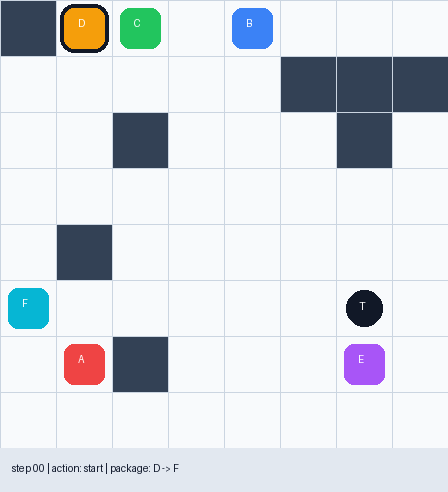

In [44]:
example_run = run_episode(valid_scenarios[0], mlp_action_model, render=True)
print("success:", example_run["success"])
print("steps:", example_run["steps"])
print("invalid pickup/dropoff:", example_run["invalid_pickup_or_dropoff"])
print("actions:", [ACTION_NAMES[a] for a in example_run["actions"]])
print("initial frame:")
print(example_run["frames"][0])
print("final frame:")
print(example_run["frames"][-1])

print("animated rollout:")
show_episode_gif(valid_scenarios[0], example_run["actions"], path="model_rollout.gif")


### 8.6 Generate Submission Files

The test set contains scenarios without expert actions. A prediction is a list of actions for each scenario.


In [45]:
def generate_predictions(scenarios, action_fn, limit=None):
    """Generate action sequences for scenarios."""
    predictions = []
    for scenario in tqdm(scenarios[:limit], desc="Generating predictions"):
        episode = run_episode(scenario, action_fn)
        predictions.append({
            "layout_id": scenario["layout_id"],
            "episode_seed": scenario["episode_seed"],
            "actions": episode["actions"],
        })
    return predictions


def save_predictions_zip(predictions, path="predictions.zip"):
    """Write predictions.jsonl into a zip file."""
    jsonl_path = Path("predictions.jsonl")
    with jsonl_path.open("w", encoding="utf-8") as f:
        for pred in predictions:
            f.write(json.dumps(pred) + "\n")
    with zipfile.ZipFile(path, "w") as zf:
        zf.write(jsonl_path, "predictions.jsonl")
    print(f"Saved {path}")


# For a real submission, use limit=None.
test_predictions_preview = generate_predictions(test_scenarios, mlp_action_model, limit=5)
test_predictions_preview[0]


Generating predictions:   0%|          | 0/5 [00:00<?, ?it/s]

{'layout_id': 'test_0000',
 'episode_seed': 300000,
 'actions': [0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  1]}

In [46]:
# Uncomment these lines to generate a full submission file.
# test_predictions = generate_predictions(test_scenarios, mlp_action_model, limit=None)
# save_predictions_zip(test_predictions, "predictions.zip")


## 9. Hints for Improvement

Here are some questions worth thinking about after you run the baseline.

### Representation

- Does the input format make the important geometry easy for the model to see?
- Are all parts of the observation equally useful, or should some parts be encoded differently?
- Does flattening the grid lose information that a model could otherwise use?

### Model

- Is the baseline model a good match for this kind of structured input?
- Should the model process the map and the numerical features in the same way?
- Can the model learn both local decisions and longer-range navigation patterns?

### Failure Analysis

- Does high action accuracy lead to high complete-episode success?
- Which episodes fail most often: before pickup, after pickup, near walls, or near the destination?
- Are there rare actions or rare situations that the model does not learn well?
- When you replay failed episodes, do the mistakes look random, systematic, or caused by earlier drift?
